# 02. Data Cleaning

## Objective

This notebook prepares the raw battery datasets for modeling.

The goals are to:

- standardize inconsistent column names across files;
- convert measurement units to a consistent representation;
- add explicit experimental metadata such as chemistry, temperature, and C-rate;
- combine multiple experiments into a single dataframe;
- validate the processed dataset before modeling.

The raw Excel files are preserved unchanged. All transformations are performed programmatically.

In [1]:
import sys
sys.path.append("../src")

from soc_prediction.data import preprocess_data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import importlib
import soc_prediction.data as data

importlib.reload(data)

<module 'soc_prediction.data' from 'c:\\Users\\bruna\\OneDrive\\Desktop\\codigos\\soc-prediction\\notebooks\\../src\\soc_prediction\\data.py'>

## Data Preprocessing

The raw battery files use inconsistent column names across temperatures and C-rates, so the preprocessing pipeline standardizes equivalent variables into a common schema.

SOC and SOE columns are renamed to `soc` and `soe`, while experimental information previously encoded in filenames and column names is stored explicitly in:

- `chemistry`
- `temperature_c`
- `c_rate`

Measurement units are also standardized:

- current: mA → A
- capacity: mAh → Ah
- energy: mWh → Wh

Unnamed columns were inspected before removal. Relevant data, such as the missing SOE trajectory in one sheet, is preserved, while unrelated spreadsheet artifacts are discarded.

Finally, all LFP experiments across 5 °C, 25 °C, and 45 °C and 0.5C, 1C, and 1.5C are combined into a single dataframe for validation and later modeling.

In [2]:
temperatures = [5, 25, 45]
c_rates = [0.5, 1.0, 1.5]

all_data = []

# loop through each temperature and C-rate combination for data import and preprocessing
for temperature in temperatures:

    file = f"../data/raw/LiFePO4/LiFePO4_{temperature}degree.xlsx"

    for c_rate in c_rates:
        
        # define the sheet name based on the C-rate
        sheet_name = f"{c_rate}C"

        # import the data from the excel file
        df = pd.read_excel(
            file,
            sheet_name=sheet_name
        )

        # preprocess the data
        df = preprocess_data(
            df,
            chemistry="LFP",
            temperature_c=temperature,
            c_rate=c_rate
        )

        all_data.append(df)


# combine all the dataframes into a single dataframe
combined_df = pd.concat(
    all_data,
    ignore_index=True
)

## Processed Dataset Validation

After preprocessing, the combined dataframe is checked for:

- expected columns;
- expected temperature and C-rate groups;
- missing values;
- duplicate rows;

These checks are performed before any train/test split or model training.

In [3]:
print(combined_df.shape)

print(combined_df.columns.tolist())

print(
    combined_df.groupby(
        ["temperature_c", "c_rate"]
    ).size()
)

(39626, 10)
['time_s', 'voltage_v', 'soc', 'soe', 'current_a', 'capacity_ah', 'energy_wh', 'chemistry', 'temperature_c', 'c_rate']
temperature_c  c_rate
5              0.5       7364
               1.0       3508
               1.5       2343
25             0.5       7213
               1.0       3602
               1.5       2398
45             0.5       7290
               1.0       3555
               1.5       2353
dtype: int64


In [4]:
print("Missing values:")
print(combined_df.isna().sum().sum())

print("Duplicate rows:")
print(combined_df.duplicated().sum())


Missing values:
0
Duplicate rows:
0


In [5]:
combined_df.head()

,time_s,voltage_v,soc,soe,current_a,capacity_ah,energy_wh,chemistry,temperature_c,c_rate
0,1,3.7382,0.000000,0.000000,-1.1986,2.457065,0.000000,LFP,5,0.5
1,2,3.7205,0.013574,0.016354,-1.2008,2.457032,0.001244,LFP,5,0.5
2,3,3.7041,0.027156,0.032643,-1.2016,2.456698,0.002482,LFP,5,0.5
3,4,3.6901,0.040743,0.048870,-1.2016,2.456364,0.003716,LFP,5,0.5
4,5,3.6765,0.054326,0.065031,-1.2023,2.456030,0.004945,LFP,5,0.5


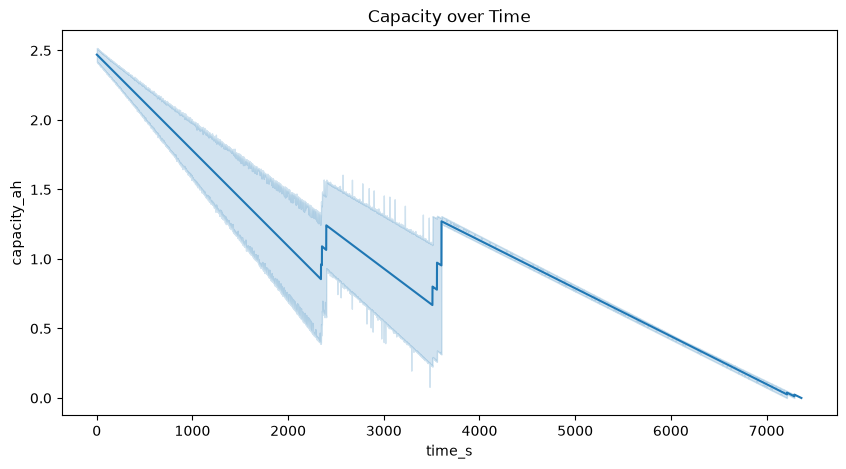

In [6]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=combined_df,
    x="time_s",
    y="capacity_ah"
)

plt.title("Capacity over Time")
plt.show()

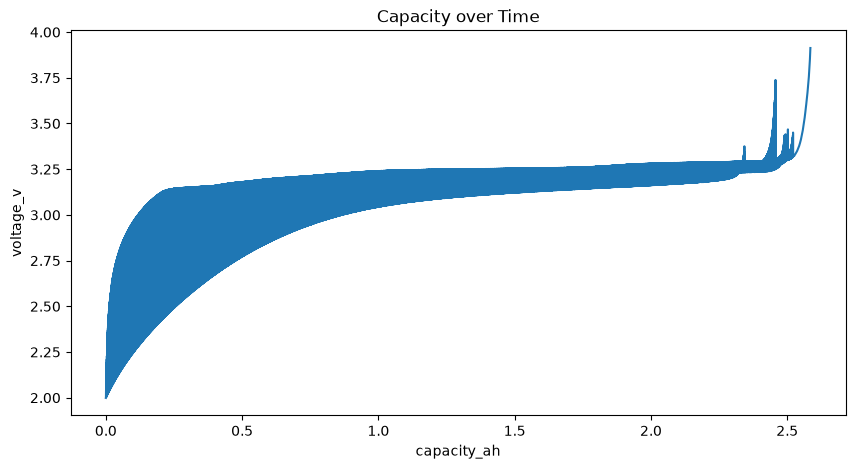

In [7]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=combined_df,
    x="capacity_ah",
    y="voltage_v"
)

plt.title("Capacity over Time")
plt.show()

## Save DataFrame

In [ ]:
combined_df.to_csv(
    "../data/processed/lfp_processed.csv",
    index=False
)

## Initial Feature Selection

The first SOC baseline will use:

- `voltage_v`
- `current_a`
- `temperature_c`
- `c_rate`

The prediction target is:

- `soc`

The following variables will not be used as initial model inputs:

- `capacity_ah`
- `energy_wh`
- `soe`
- `time_s`

Accumulated capacity is strongly related to the provided SOC target and may introduce target leakage.

Energy and time are also accumulated or experiment-progress variables and are excluded from the first baseline so that the model relies primarily on electrical measurements and operating conditions.

In [ ]:
features = [
    "voltage_v",
    "current_a",
    "temperature_c",
    "c_rate"
]

target = "soc"

## Train/Test Strategy

The first baseline will evaluate generalization across temperature.

The planned split is:

- Training data: 5 °C and 25 °C
- Test data: 45 °C

Individual rows will not be randomly shuffled between training and test sets because neighboring observations belong to the same continuous experiment and are strongly correlated.

The 45 °C experiments are therefore treated as an unseen operating condition.

## Conclusion

Preprocessing is complete for the current LFP subset.

Raw schema differences were standardized, units were converted, experimental metadata was made explicit, and all temperature/C-rate combinations were combined into a single dataframe.

Potential leakage-related variables were identified and excluded from the first feature set.

The next stage will create the train/test split and establish a simple SOC baseline model.